# DeepfakeFusionModel V8 — Explicit rPPG + Temporal MLP + Fair Ablation

## Tất cả vấn đề từ phân tích V7 đã được giải quyết

| Vấn đề V7 | Giải pháp V8 |
|---|---|
| T=32 (1.28s) — chỉ 1 chu kỳ tim | **T=64 (2.56s)** — ≥2 chu kỳ tim, 25 FPS |
| Không có explicit rPPG signal | **`ChrominanceSignalHead`** — tính mean Cr/Cb theo thời gian → 1D CNN, thêm vào token |
| Mean pooling phá hủy temporal order | **`TemporalMLP`** — Flatten → Linear(16×BIO_TOKENS×DIM) giữ thứ tự |
| ABLATION_EPOCHS=10, không công bằng (Swin pretrained vs rPPG random) | **ABLATION_EPOCHS=25** cho mọi variant; rPPG-only dùng BCE thuần (không label smooth) |
| FACE_SIZE=112 — mất chi tiết màu | **FACE_SIZE=128** — chi tiết hơn cho Cr/Cb |
| CLIPS_PER_VIDEO=3 — quá ít | **CLIPS_PER_VIDEO=5** |
| BATCH_SIZE=8 — BatchNorm không ổn định | **Gradient accumulation ACCUM_STEPS=4** → effective batch=32 |
| FFN bottleneck 768→192→768 (sai tiêu chuẩn) | **FFN expansion 768→3072→768** (Vaswani et al. chuẩn) |
| CLIPS_DIR dùng chung với V7 — T đổi gây xung đột | **CLIPS_DIR='/content/clips_v8'** riêng biệt |

## Kiến trúc V8

```
RGB frame (middle of clip)
  → Swin-Small (pretrained)        → 768-d spatial feature ──────────────────┐
                                                              StackedCrossAttn  │ (2 layers, 8 heads)
YCrCb clip (T=64 frames)                                      Q=spatial(1 tok) │
  → rPPGNetwork3D (3D CNN 4 blocks)  → (BIO_TOKENS=32, 64) tokens            │
  + ChrominanceSignalHead             mean(Cr)/mean(Cb) per frame → 1D CNN    │
    signal broadcast to each token ──────────────────────────── KV(32 tokens) ┘
                                                                    ↓
                                                              MLP(768→256→128→1) → Sigmoid
                                                              (+ aux head on temporal tokens)
```


---
## Section 0: Environment Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q timm mediapipe scikit-learn matplotlib seaborn tqdm scipy
!wget -q -O /tmp/blaze_face_short_range.tflite \
  https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 153.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 17.3 MB/s eta 0:00:00


In [3]:
import os, glob, random, time, warnings, gc
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
import mediapipe as mp
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU:   {torch.cuda.get_device_name(0)}')
    print(f'VRAM:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU:   NVIDIA A100-SXM4-80GB
VRAM:  85.1 GB


In [4]:
class Config:
    # ── Paths ──
    DRIVE_ROOT   = '/content/drive/MyDrive/DoAn_Nhom4'
    FF_ZIP       = f'{DRIVE_ROOT}/FaceForensics.zip'
    CELEB_ZIP    = f'{DRIVE_ROOT}/Celeb-DF-v2.zip'
    EXTRACT_DIR  = '/content/dataset'
    # FIX: dùng thư mục riêng vì T=64 khác V7 (T=32) — clip .npy không tương thích
    CLIPS_DIR    = '/content/clips_v8'
    FF_CLIPS     = f'{CLIPS_DIR}/ffpp'
    CELEB_CLIPS  = f'{CLIPS_DIR}/celeb_df_v2'
    SAVE_DIR     = f'{DRIVE_ROOT}/weights_v8'

    # ── Clip Extraction ──
    # FIX 1: T=64 @ 25fps = 2.56s → ≥2 chu kỳ tim (60bpm=1Hz → 2 beats)
    #   V7 dùng T=32 (1.28s ≈ 1 beat) — không đủ thông tin rPPG
    T                 = 64
    CLIPS_PER_VIDEO   = 5     # FIX 6: tăng từ 3 → 5 để phủ nhiều đoạn hơn
    FACE_CONFIDENCE   = 0.7
    FACE_PAD_X        = 0.15
    FACE_PAD_Y_TOP    = 0.40
    FACE_PAD_Y_BOTTOM = 0.20
    # FIX 4: 128×128 thay vì 112×112 — biến thiên Cr/Cb ở 112×112 dễ mất chi tiết
    FACE_SIZE         = 128

    # ── Model ──
    SPATIAL_DIM = 768      # Swin-Small output dim
    BIO_DIM     = 64       # rPPG per-token feature dim
    BIO_TOKENS  = T // 2   # = 32 temporal tokens (T=64 → 32 tokens)
    ATTN_HEADS  = 8        # 768/8=96 → OK
    DROPOUT     = 0.3
    CROSS_ATTN_LAYERS = 2
    # FIX 8: FFN expansion ratio — chuẩn Transformer: spatial_dim * ratio = 768*4 = 3072
    FFN_EXPAND  = 4        # V7 dùng spatial_dim//4=192 (bottleneck, sai chuẩn)

    # ── Training ──
    BATCH_SIZE           = 8
    # FIX 7: gradient accumulation → effective batch = 8 * 4 = 32
    #   BatchNorm3d trong rPPGNetwork3D không ổn với batch nhỏ
    ACCUM_STEPS          = 4
    EPOCHS               = 25
    FREEZE_SWIN_EPOCHS   = 3
    LR_SWIN              = 2e-5
    LR_OTHER             = 1e-4
    WEIGHT_DECAY         = 1e-4
    LABEL_SMOOTHING      = 0.05
    EARLY_STOP_PATIENCE  = 5
    GRAD_CLIP            = 1.0
    # FIX 5: ABLATION_EPOCHS=25 cho TẤT CẢ variant
    #   V7 dùng 10 epochs — không công bằng vì Swin đã có ImageNet prior,
    #   còn rPPG bắt đầu từ random weights → cần nhiều epoch hơn
    ABLATION_EPOCHS      = 25

    SEED = 42


def set_seed(seed=Config.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
for k, v in vars(Config).items():
    if not k.startswith('_'):
        print(f'  {k:<22} = {v}')


  DRIVE_ROOT             = /content/drive/MyDrive/DoAn_Nhom4
  FF_ZIP                 = /content/drive/MyDrive/DoAn_Nhom4/FaceForensics.zip
  CELEB_ZIP              = /content/drive/MyDrive/DoAn_Nhom4/Celeb-DF-v2.zip
  EXTRACT_DIR            = /content/dataset
  CLIPS_DIR              = /content/clips_v8
  FF_CLIPS               = /content/clips_v8/ffpp
  CELEB_CLIPS            = /content/clips_v8/celeb_df_v2
  SAVE_DIR               = /content/drive/MyDrive/DoAn_Nhom4/weights_v8
  T                      = 64
  CLIPS_PER_VIDEO        = 5
  FACE_CONFIDENCE        = 0.7
  FACE_PAD_X             = 0.15
  FACE_PAD_Y_TOP         = 0.4
  FACE_PAD_Y_BOTTOM      = 0.2
  FACE_SIZE              = 128
  SPATIAL_DIM            = 768
  BIO_DIM                = 64
  BIO_TOKENS             = 32
  ATTN_HEADS             = 8
  DROPOUT                = 0.3
  CROSS_ATTN_LAYERS      = 2
  FFN_EXPAND             = 4
  BATCH_SIZE             = 8
  ACCUM_STEPS            = 4
  EPOCHS                 = 25
  F

---
## Section 1: Dataset Preparation — Video → Face Clips

**Đặc điểm chính của cách chuẩn bị dữ liệu:**  
Mỗi clip bao gồm **T=32 frame liên tiếp** từ same một video (≈ 1.2 giây ở 25fps),
lưu dưới dạng `.npy` shape `(32, FACE_SIZE, FACE_SIZE, 3)` (BGR).  
Đoạn video dài này cho phép nhánh rPPG phân tích biến động màu sắc theo thời gian
với độ phân giải cao, bao trùm hơn 1 chu kỳ tim.

> **Note:** Chỉ cần chạy Section 1 một lần. Nếu clips đã tồn tại, bỏ qua đến Section 2.

In [5]:
os.makedirs(Config.EXTRACT_DIR, exist_ok=True)

# Unzip FaceForensics++
ff_folders = glob.glob(os.path.join(Config.EXTRACT_DIR, 'FaceForensics*'))
if not ff_folders:
    print('Extracting FaceForensics++...')
    !unzip -q "{Config.FF_ZIP}" -d "{Config.EXTRACT_DIR}/"
    ff_folders = glob.glob(os.path.join(Config.EXTRACT_DIR, 'FaceForensics*'))
FF_ROOT = ff_folders[0]
print(f'FF++ root: {FF_ROOT}')
!ls "{FF_ROOT}"

# Unzip Celeb-DF-v2
celeb_folders = glob.glob(os.path.join(Config.EXTRACT_DIR, 'Celeb*'))
if not celeb_folders:
    print('\nExtracting Celeb-DF-v2...')
    !unzip -q "{Config.CELEB_ZIP}" -d "{Config.EXTRACT_DIR}/"
    celeb_folders = glob.glob(os.path.join(Config.EXTRACT_DIR, 'Celeb*'))
CELEB_ROOT = celeb_folders[0]
# Handle possible nested folder structure
if not any(os.path.isdir(os.path.join(CELEB_ROOT, d))
           for d in ['Celeb-real', 'Celeb-synthesis']):
    for s in glob.glob(os.path.join(CELEB_ROOT, '*')):
        if os.path.isdir(s) and 'Celeb-real' in os.listdir(s):
            CELEB_ROOT = s
            break
print(f'Celeb-DF-v2 root: {CELEB_ROOT}')
!ls "{CELEB_ROOT}"

Extracting FaceForensics++...
FF++ root: /content/dataset/FaceForensics++_C23
csv		   Deepfakes  FaceShifter  NeuralTextures
DeepFakeDetection  Face2Face  FaceSwap	   original

Extracting Celeb-DF-v2...
Celeb-DF-v2 root: /content/dataset/Celeb-synthesis
id0_id1_0000.mp4    id23_id37_0006.mp4	id32_id37_0000.mp4  id47_id42_0009.mp4
id0_id1_0001.mp4    id23_id37_0007.mp4	id32_id37_0002.mp4  id47_id43_0000.mp4
id0_id1_0002.mp4    id23_id37_0008.mp4	id32_id37_0004.mp4  id47_id43_0001.mp4
id0_id1_0003.mp4    id23_id37_0009.mp4	id32_id37_0005.mp4  id47_id43_0002.mp4
id0_id1_0005.mp4    id23_id38_0000.mp4	id32_id37_0006.mp4  id47_id43_0003.mp4
id0_id1_0006.mp4    id23_id38_0001.mp4	id32_id37_0007.mp4  id47_id43_0004.mp4
id0_id1_0007.mp4    id23_id38_0002.mp4	id32_id37_0008.mp4  id47_id43_0005.mp4
id0_id1_0009.mp4    id23_id38_0003.mp4	id32_id37_0009.mp4  id47_id43_0006.mp4
id0_id16_0000.mp4   id23_id38_0004.mp4	id32_id38_0000.mp4  id47_id43_0007.mp4
id0_id16_0001.mp4   id23_id38_0005.mp4	id32_

In [6]:
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

def extract_clips_from_video(video_path, output_dir, detector):
    '''
    Trích xuất face clips từ video dùng MediaPipe Tasks API (mediapipe >= 0.10.14).
    '''
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return 0

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < Config.T:
        cap.release()
        return 0

    video_id = os.path.splitext(os.path.basename(video_path))[0]
    os.makedirs(output_dir, exist_ok=True)

    # ── Detect face trong frame đầu ─────────────────────────────────────────
    ret, first_frame = cap.read()
    if not ret:
        cap.release()
        return 0

    rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

    # Tasks API: use mp.Image instead of process(rgb)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result   = detector.detect(mp_image)

    if not result.detections:
        cap.release()
        return 0

    det = result.detections[0]
    bb  = det.bounding_box          # BoundingBox object (Tasks API)
    ih, iw = first_frame.shape[:2]

    # Tasks API returns pixel coords directly (not relative like solutions)
    x, y = bb.origin_x, bb.origin_y
    w, h = bb.width, bb.height

    px = int(w * Config.FACE_PAD_X)
    pt = int(h * Config.FACE_PAD_Y_TOP)
    pb = int(h * Config.FACE_PAD_Y_BOTTOM)
    x1 = max(0, x - px);      y1 = max(0, y - pt)
    x2 = min(iw, x + w + px); y2 = min(ih, y + h + pb)

    if (x2 - x1) < 20 or (y2 - y1) < 20:
        cap.release()
        return 0

    # ── Extract clips ──────────────────────────────────────────────────────────
    max_start  = total - Config.T
    clip_starts = np.linspace(0, max_start, Config.CLIPS_PER_VIDEO, dtype=int)
    saved = 0

    for clip_idx, start in enumerate(clip_starts):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(start))
        frames = []
        for _ in range(Config.T):
            ret, frame = cap.read()
            if not ret:
                break
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                break
            frames.append(cv2.resize(crop, (Config.FACE_SIZE, Config.FACE_SIZE),
                                     interpolation=cv2.INTER_LINEAR))

        if len(frames) == Config.T:
            np.save(os.path.join(output_dir,
                                 f'{video_id}_clip{clip_idx:02d}.npy'),
                    np.stack(frames, axis=0))
            saved += 1

    cap.release()
    return saved


def process_video_folders(video_dirs, output_dir):
    '''Process all videos in the directory list — use MediaPipe Tasks API.'''
    # Initialize detector ONCE outside the loop (avoid overhead)
    base_options    = mp_python.BaseOptions(
        model_asset_path='/tmp/blaze_face_short_range.tflite')
    options         = mp_vision.FaceDetectorOptions(
        base_options=base_options,
        min_detection_confidence=Config.FACE_CONFIDENCE)
    detector = mp_vision.FaceDetector.create_from_options(options)

    videos = []
    for vdir in video_dirs:
        if not os.path.isdir(vdir):
            continue
        for ext in ['*.mp4', '*.avi', '*.mov', '*.mkv']:
            videos.extend(glob.glob(os.path.join(vdir, '**', ext), recursive=True))

    print(f'  Found {len(videos)} videos')
    total_clips = 0
    for vp in tqdm(videos, desc='  Extracting clips'):
        total_clips += extract_clips_from_video(vp, output_dir, detector)

    detector.close()
    n_clips = len(glob.glob(os.path.join(output_dir, '*.npy')))
    print(f'  Saved {n_clips} clips total.')
    return n_clips

print('Clip extraction functions ready.')

Clip extraction functions ready.


In [7]:
# ── Extract FF++ clips ─────────────────────────────────────────────────────────
print('=' * 60)
print('EXTRACTING CLIPS FROM FACEFORENSICS++ (C23)')
print('=' * 60)

ff_real_dir = os.path.join(Config.FF_CLIPS, 'real')
ff_fake_dir = os.path.join(Config.FF_CLIPS, 'fake')

if os.path.exists(ff_real_dir) and len(glob.glob(f'{ff_real_dir}/*.npy')) > 100:
    n_real = len(glob.glob(f'{ff_real_dir}/*.npy'))
    n_fake = len(glob.glob(f'{ff_fake_dir}/*.npy'))
    print(f'FF++ clips already exist — Real: {n_real}, Fake: {n_fake}. Skipping.')
else:
    print('\n[REAL] original/')
    process_video_folders([os.path.join(FF_ROOT, 'original')], ff_real_dir)

    print('\n[FAKE] 5 manipulation methods:')
    for method in ['Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']:
        mdir = os.path.join(FF_ROOT, method)
        if os.path.isdir(mdir):
            print(f'  >> {method}')
            process_video_folders([mdir], ff_fake_dir)
        else:
            print(f'  >> {method} NOT FOUND — skipping.')

print(f'\nFF++ done: Real={len(glob.glob(f"{ff_real_dir}/*.npy"))} clips, '
      f'Fake={len(glob.glob(f"{ff_fake_dir}/*.npy"))} clips')

EXTRACTING CLIPS FROM FACEFORENSICS++ (C23)

[REAL] original/
  Found 1000 videos


  Extracting clips:   0%|          | 0/1000 [00:00<?, ?it/s]

  Saved 4685 clips total.

[FAKE] 5 manipulation methods:
  >> Deepfakes
  Found 1000 videos


  Extracting clips:   0%|          | 0/1000 [00:00<?, ?it/s]

  Saved 4660 clips total.
  >> Face2Face
  Found 1000 videos


...

  Saved 4760 clips total.
  >> FaceSwap
  Found 1000 videos


  Extracting clips:   0%|          | 0/1000 [00:00<?, ?it/s]

  Saved 4770 clips total.
  >> NeuralTextures
  Found 1000 videos


  Extracting clips:   0%|          | 0/1000 [00:00<?, ?it/s]

  Saved 4770 clips total.

FF++ done: Real=4685 clips, Fake=4770 clips


In [8]:
# ── Extract Celeb-DF-v2 clips ─────────────────────────────────────────────────
print('=' * 60)
print('EXTRACTING CLIPS FROM CELEB-DF-v2')
print('=' * 60)

celeb_real_dir = os.path.join(Config.CELEB_CLIPS, 'real')
celeb_fake_dir = os.path.join(Config.CELEB_CLIPS, 'fake')

if os.path.exists(celeb_real_dir) and len(glob.glob(f'{celeb_real_dir}/*.npy')) > 100:
    print('Celeb-DF-v2 clips already exist. Skipping.')
else:
    print('[REAL] Celeb-real + YouTube-real')
    # Fix: Celeb folders are directly inside Config.EXTRACT_DIR
    process_video_folders(
        [os.path.join(Config.EXTRACT_DIR, 'Celeb-real'),
         os.path.join(Config.EXTRACT_DIR, 'YouTube-real')], celeb_real_dir)

    print('[FAKE] Celeb-synthesis')
    process_video_folders([os.path.join(Config.EXTRACT_DIR, 'Celeb-synthesis')], celeb_fake_dir)

print(f'Celeb-DF-v2 done: Real={len(glob.glob(f"{celeb_real_dir}/*.npy"))} clips, '
      f'Fake={len(glob.glob(f"{celeb_fake_dir}/*.npy"))} clips')

EXTRACTING CLIPS FROM CELEB-DF-v2
[REAL] Celeb-real + YouTube-real
  Found 890 videos


  Extracting clips:   0%|          | 0/890 [00:00<?, ?it/s]

  Saved 4170 clips total.
[FAKE] Celeb-synthesis
  Found 5639 videos


  Extracting clips:   0%|          | 0/5639 [00:00<?, ?it/s]

  Saved 27265 clips total.
Celeb-DF-v2 done: Real=4170 clips, Fake=27265 clips


---
## Section 2: Dataset Class & DataLoader

**Dataset design for temporal input:**
- Mỗi sample = 1 clip `.npy` có shape `(T, H, W, 3)` BGR
- **Spatial branch**: middle frame (index T//2) → RGB → Swin transform
- **Bio branch**: all T frames → YCrCb → normalize [0,1] → shape `(T, 3, 64, 64)`
- Geometric augmentation applied **consistently** to all T frames (same flip/rotate)
- ColorJitter applied only to the spatial branch:
  reason — bio branch needs to preserve YCrCb colors so the model learns temporal color variation

In [9]:
class DeepfakeDataset(Dataset):
    '''
    Temporal dual-stream dataset for deepfake detection.

    Load pre-extracted face clips (.npy, shape: T × H × W × 3 BGR).
    Returns:
        spatial_input : (3, 224, 224) float         — ImageNet-normalized RGB middle frame
        bio_input     : (T, 3, 128, 128) float      — YCrCb clip, normalized [0, 1]
        label         : scalar float                 — 0=real, 1=fake

    V8 change: BIO_SIZE=128 (was 112) — higher resolution preserves subtle Cr/Cb variations.
    ColorJitter removed from __getitem__ (already in train_spatial_tf) to avoid double application.
    '''
    BIO_SIZE = Config.FACE_SIZE  # 128 — match FACE_SIZE for consistency

    def __init__(self, npy_paths, labels, spatial_tf, augment=False):
        self.paths      = npy_paths
        self.labels     = labels
        self.spatial_tf = spatial_tf
        self.augment    = augment

    def __len__(self):
        return len(self.paths)

    def _augment_consistent(self, frames_bgr):
        '''
        Apply geometric augmentation to ALL T frames with the SAME random transform.
        Critical for temporal coherence: rPPG signal requires consistent inter-frame
        pixel correspondence — different transforms per frame would corrupt the signal.
        '''
        do_flip   = random.random() > 0.5
        do_rotate = random.random() > 0.5
        angle = random.uniform(-10, 10) if do_rotate else 0.0

        h, w = frames_bgr[0].shape[:2]
        M = (cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
             if do_rotate else None)

        out = []
        for f in frames_bgr:
            if do_flip:
                f = cv2.flip(f, 1)
            if do_rotate:
                f = cv2.warpAffine(f, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
            out.append(f)
        return out

    def __getitem__(self, idx):
        clip_bgr = np.load(self.paths[idx], allow_pickle=False)  # (T, H, W, 3)
        label    = self.labels[idx]

        frames = [clip_bgr[t] for t in range(Config.T)]

        # Consistent geometric augmentation across all T frames
        if self.augment:
            frames = self._augment_consistent(frames)

        mid = Config.T // 2

        # ── Spatial Branch: RGB middle frame ──────────────────────────────────
        frame_spatial = frames[mid].copy()
        if self.augment and random.random() > 0.5:
            if random.random() > 0.5:
                quality = random.randint(30, 95)
                _, buf = cv2.imencode('.jpg', frame_spatial,
                                      [int(cv2.IMWRITE_JPEG_QUALITY), quality])
                frame_spatial = cv2.imdecode(buf, cv2.IMREAD_COLOR)
            else:
                scale = random.uniform(0.5, 0.9)
                h, w = frame_spatial.shape[:2]
                small = cv2.resize(frame_spatial, (int(w*scale), int(h*scale)))
                frame_spatial = cv2.resize(small, (w, h))

        frame_rgb = cv2.cvtColor(frame_spatial, cv2.COLOR_BGR2RGB)
        spatial_input = self.spatial_tf(Image.fromarray(frame_rgb))  # (3, 224, 224)

        # ── Bio Branch: YCrCb clip → rPPG 3D CNN ─────────────────────────────
        # NOTE: ColorJitter intentionally NOT applied here —
        #   (a) already handled in train_spatial_tf for spatial branch,
        #   (b) color jitter corrupts the temporal Cr/Cb signal we need for rPPG.
        bio_frames = []
        for f in frames:
            ycrcb = cv2.cvtColor(f, cv2.COLOR_BGR2YCrCb)
            ycrcb = cv2.resize(ycrcb, (self.BIO_SIZE, self.BIO_SIZE),
                               interpolation=cv2.INTER_LINEAR)
            bio_frames.append(ycrcb)

        # (T, H, W, 3) uint8 → (T, 3, H, W) float [0, 1]
        bio_array = np.stack(bio_frames, axis=0).astype(np.float32) / 255.0
        bio_input = torch.from_numpy(bio_array).permute(0, 3, 1, 2)  # (T, 3, H, W)

        return spatial_input, bio_input, torch.tensor(label, dtype=torch.float32)


print('DeepfakeDataset defined (BIO_SIZE=128, no double ColorJitter).')


DeepfakeDataset defined (BIO_SIZE=128, no double ColorJitter).


In [10]:
train_spatial_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_spatial_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def collect_npy(base_dir):
    '''Collect .npy clip paths and labels from real/ and fake/ subfolders.'''
    paths, labels = [], []
    for label_name, label_val in [('real', 0), ('fake', 1)]:
        folder = os.path.join(base_dir, label_name)
        if not os.path.exists(folder):
            continue
        for f in sorted(glob.glob(os.path.join(folder, '*.npy'))):
            paths.append(f)
            labels.append(label_val)
    return paths, labels


def get_video_id(npy_path):
    '''
    Extract video_id from clip name.
    Format: "{video_id}_clip{NN}.npy" → "{video_id}"
    Use rfind to avoid false-split if video_id contains "_clip" in the name.
    '''
    name = os.path.splitext(os.path.basename(npy_path))[0]
    idx  = name.rfind('_clip')
    return name[:idx] if idx != -1 else name


# ── Collect FF++ data ──────────────────────────────────────────────────────────
ff_paths, ff_labels = collect_npy(Config.FF_CLIPS)
print(f'FF++ total: {len(ff_paths)} clips '
      f'(Real: {ff_labels.count(0)}, Fake: {ff_labels.count(1)})')

# ── Split by video ID — avoid data leakage (frames from same video in same split) ─────
video_ids = sorted(set(get_video_id(p) for p in ff_paths))
random.shuffle(video_ids)
split = int(len(video_ids) * 0.8)
train_vids = set(video_ids[:split])
val_vids   = set(video_ids[split:])

train_paths, train_labels = [], []
val_paths,   val_labels   = [], []

for p, l in zip(ff_paths, ff_labels):
    if get_video_id(p) in train_vids:
        train_paths.append(p);  train_labels.append(l)
    else:
        val_paths.append(p);    val_labels.append(l)

print(f'FF++ Train: {len(train_paths)} clips '
      f'(Real: {train_labels.count(0)}, Fake: {train_labels.count(1)})')
print(f'FF++ Val:   {len(val_paths)} clips '
      f'(Real: {val_labels.count(0)}, Fake: {val_labels.count(1)})')

# ── Celeb-DF-v2: cross-dataset test (untouched during train/val) ────────────
celeb_paths, celeb_labels = collect_npy(Config.CELEB_CLIPS)
print(f'\nCeleb-DF-v2 Test: {len(celeb_paths)} clips '
      f'(Real: {celeb_labels.count(0)}, Fake: {celeb_labels.count(1)})')

FF++ total: 9455 clips (Real: 4685, Fake: 4770)
FF++ Train: 7560 clips (Real: 3695, Fake: 3865)
FF++ Val:   1895 clips (Real: 990, Fake: 905)

Celeb-DF-v2 Test: 31435 clips (Real: 4170, Fake: 27265)


In [11]:
train_dataset = DeepfakeDataset(train_paths, train_labels, train_spatial_tf, augment=True)
val_dataset   = DeepfakeDataset(val_paths,   val_labels,   val_spatial_tf, augment=False)
test_dataset  = DeepfakeDataset(celeb_paths, celeb_labels, val_spatial_tf, augment=False)

# WeightedRandomSampler to balance class imbalance (FF++ has more fakes than reals)
counts         = np.bincount(train_labels)
sample_weights = [1.0 / counts[l] for l in train_labels]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights),
                                       replacement=True)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE,
                          sampler=sampler, num_workers=0,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f'DataLoaders ready:')
print(f'  Train: {len(train_loader)} batches × {Config.BATCH_SIZE}')
print(f'  Val:   {len(val_loader)} batches')
print(f'  Test:  {len(test_loader)} batches (Celeb-DF-v2)')

DataLoaders ready:
  Train: 945 batches × 8
  Val:   237 batches
  Test:  3930 batches (Celeb-DF-v2)


---
## Section 3: Model Architecture — DeepfakeFusionModel V7

### rPPGNetwork3D — outputs a TOKEN SEQUENCE (16 tokens)
3D CNN comprising 4 blocks processing T=32 YCrCb frames. The final block uses
`AdaptiveAvgPool3d((BIO_TOKENS,1,1))` — only spatial pooling, **preserving `BIO_TOKENS=16`
temporal tokens**. This is a necessary design for Cross-Attention to have true
mathematical meaning.

### StackedCrossAttentionFusion — 2-layer stacked cross-attention
`nn.MultiheadAttention` với `num_heads = 8`, stacked 2 layers.
Each layer consists of: Multi-Head Cross-Attention + FFN + Residual + LayerNorm.
- **Query**: 1 token from spatial branch (Swin-Small) — *"spatial features on the face"*
- **Key/Value**: 16 token from bio branch (rPPG) — *"biological signals at 16 time segments"*

The first layer learns to select relevant temporal information. The second layer further refines
based on the fusion results of the previous layer, allowing integration at multiple abstraction levels.


In [12]:
class ChrominanceSignalHead(nn.Module):
    '''
    FIX 2 — Explicit rPPG signal extractor (new in V8).

    Motivation: rPPGNetwork3D must learn pulse extraction, denoising, and
    classification all simultaneously from raw pixels. FakeCatcher explicitly
    provides rPPG traces as input. This module bridges that gap.

    Operation:
      1. Compute spatial mean of Cr and Cb channels per frame → (B, T, 2) traces.
         These are proxies for the rPPG signal (blood-volume pulse changes skin
         reflectance in the Cr and Cb channels at cardiac frequency ≈1Hz).
      2. Feed traces through a 1D CNN to extract temporal frequency features.
      3. Output a (B, BIO_DIM) embedding that is broadcast-added to each 3D CNN
         token, providing an explicit physiological prior at every temporal position.

    Input:  (B, T, 3, H, W) — YCrCb bio clip (channel 1=Cr, 2=Cb)
    Output: (B, BIO_DIM)    — chrominance signal embedding
    '''
    def __init__(self, T=Config.T, bio_dim=Config.BIO_DIM):
        super().__init__()
        # 1D CNN on temporal chrominance traces
        # Input: (B, 2, T) — 2 channels (Cr, Cb), T time steps
        self.signal_cnn = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=7, padding=3),   # capture slow pulse cycles
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),                       # (B, 64, 1)
        )
        self.proj = nn.Sequential(
            nn.Linear(64, bio_dim),
            nn.LayerNorm(bio_dim)
        )

    def forward(self, bio_input):
        # bio_input: (B, T, 3, H, W) — YCrCb
        B, T, C, H, W = bio_input.shape
        # Spatial mean per channel per frame
        # Cr = channel index 1, Cb = channel index 2
        cr = bio_input[:, :, 1, :, :].mean(dim=(-1, -2))  # (B, T)
        cb = bio_input[:, :, 2, :, :].mean(dim=(-1, -2))  # (B, T)
        signal = torch.stack([cr, cb], dim=1)              # (B, 2, T)
        feat = self.signal_cnn(signal).squeeze(-1)         # (B, 64)
        return self.proj(feat)                             # (B, BIO_DIM)


class rPPGNetwork3D(nn.Module):
    '''
    Temporal Physiological Feature Extractor — TOKEN SEQUENCE + explicit signal.

    V8 changes:
      - T=64 frames (was 32): captures 2.56s ≥ 2 heart cycles at 60bpm
      - BIO_SIZE=128 (was 112): more spatial detail for Cr/Cb variations
      - BIO_TOKENS=32 (was 16): finer temporal granularity in KV for cross-attention
      - Added ChrominanceSignalHead: explicit rPPG proxy signal broadcast to each token

    Input:  (B, T=64, 3, 128, 128) — YCrCb face clips
    Output: (B, BIO_TOKENS=32, BIO_DIM=64) — enriched temporal token sequence

    Block design (with T=64, BIO_SIZE=128):
      Block 1:  (B, 3,   64, 128, 128) → (B, 32,  64, 64, 64)  [pool spatial only]
      Block 2:  (B, 32,  64, 64,  64)  → (B, 64,  32, 32, 32)  [pool spatial + temporal]
      Block 2b: (B, 64,  32, 32,  32)  → (B, 128, 32, 16, 16)  [pool spatial only, deeper]
      Block 3:  (B, 128, 32, 16,  16)  → (B, 64,  32, 1,  1)   [adaptive pool]
      + ChrominanceSignalHead output broadcast-added to each token
    '''
    def __init__(self, bio_dim=Config.BIO_DIM, bio_tokens=Config.BIO_TOKENS):
        super().__init__()
        self.bio_tokens = bio_tokens

        # 3D CNN — spatial-temporal feature extractor
        self.features = nn.Sequential(
            # Block 1: spatial pool only — keep full temporal resolution (T=64)
            nn.Conv3d(3, 32, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),

            # Block 2: pool both temporal and spatial (T: 64 → 32)
            nn.Conv3d(32, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),

            # Block 2b: deeper — pool ONLY spatial, KEEP temporal at T//2=32
            nn.Conv3d(64, 128, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),

            # Block 3: project to bio_dim, keep bio_tokens temporal positions
            nn.Conv3d(128, bio_dim, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(bio_dim),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((bio_tokens, 1, 1))  # (B, bio_dim, bio_tokens, 1, 1)
        )

        # FIX 2: Explicit chrominance signal head
        self.signal_head = ChrominanceSignalHead(T=Config.T, bio_dim=bio_dim)

        # Learnable gate: how much signal to add to each token
        # Prevents the signal from overwhelming the 3D CNN features
        self.signal_gate = nn.Sequential(
            nn.Linear(bio_dim, bio_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, T, 3, H, W) — dataset format

        # 3D CNN branch
        x_perm = x.permute(0, 2, 1, 3, 4).contiguous()  # (B, 3, T, H, W)
        feat   = self.features(x_perm)                    # (B, bio_dim, bio_tokens, 1, 1)
        feat   = feat.squeeze(-1).squeeze(-1)             # (B, bio_dim, bio_tokens)
        tokens = feat.permute(0, 2, 1).contiguous()       # (B, bio_tokens, bio_dim)

        # Explicit chrominance signal branch
        signal_feat = self.signal_head(x)                 # (B, bio_dim)
        gate        = self.signal_gate(signal_feat)        # (B, bio_dim) in (0,1)

        # Broadcast-add gated signal to each token
        # (B, 1, bio_dim) * (B, 1, bio_dim) broadcast → (B, bio_tokens, bio_dim)
        signal_contrib = gate.unsqueeze(1) * signal_feat.unsqueeze(1)
        tokens = tokens + signal_contrib                   # modulate all tokens

        return tokens  # (B, bio_tokens, bio_dim)


print('rPPGNetwork3D + ChrominanceSignalHead defined.')
print(f'Expected output: (B, {Config.BIO_TOKENS}, {Config.BIO_DIM})')


rPPGNetwork3D + ChrominanceSignalHead defined.
Expected output: (B, 32, 64)


In [13]:
class CrossAttentionLayer(nn.Module):
    '''
    Single Cross-Attention layer with full Transformer block:
      1. Multi-Head Cross-Attention (Q from spatial, K/V from bio tokens)
      2. Add + LayerNorm (residual)
      3. Feed-Forward Network with EXPANSION (not bottleneck)
      4. Add + LayerNorm (residual)

    FIX 8 (V8): FFN uses expansion ratio ffn_expand=4 → hidden=3072 (was 192).
      Standard Transformer (Vaswani et al., 2017): hidden_dim = embed_dim * 4.
      V7 mistakenly used embed_dim // 4 = 192 (a bottleneck, non-standard).
    '''
    def __init__(self, spatial_dim, num_heads, dropout=0.1,
                 ffn_expand=Config.FFN_EXPAND):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=spatial_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm1    = nn.LayerNorm(spatial_dim)
        self.norm2    = nn.LayerNorm(spatial_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        # FIX: standard expansion (768*4=3072), not bottleneck (768//4=192)
        ffn_hidden = spatial_dim * ffn_expand
        self.ffn = nn.Sequential(
            nn.Linear(spatial_dim, ffn_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_hidden, spatial_dim),
        )

    def forward(self, query, key_value, return_attn=False):
        '''
        query    : (B, 1, D)           — spatial query token
        key_value: (B, BIO_TOKENS, D)  — projected bio key/value tokens
        '''
        attended, attn_w = self.cross_attn(
            query, key_value, key_value,
            need_weights=True, average_attn_weights=True)
        query = self.norm1(query + self.dropout1(attended))
        query = self.norm2(query + self.dropout2(self.ffn(query)))

        if return_attn:
            return query, attn_w
        return query


class StackedCrossAttentionFusion(nn.Module):
    '''
    N stacked Cross-Attention layers (N=2 in V8).
    Q = 1 spatial token (from Swin), K/V = BIO_TOKENS=32 physiological tokens.
    Each layer progressively refines Q by attending over K/V.
    '''
    def __init__(self, spatial_dim=Config.SPATIAL_DIM, bio_dim=Config.BIO_DIM,
                 num_heads=Config.ATTN_HEADS, num_layers=Config.CROSS_ATTN_LAYERS,
                 dropout=0.1):
        super().__init__()
        assert spatial_dim % num_heads == 0
        self.bio_proj = nn.Sequential(
            nn.Linear(bio_dim, spatial_dim),
            nn.LayerNorm(spatial_dim)
        )
        self.layers = nn.ModuleList([
            CrossAttentionLayer(spatial_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, spatial_feat, bio_tokens, return_attn=False):
        Q  = spatial_feat.unsqueeze(1)   # (B, 1, 768)
        KV = self.bio_proj(bio_tokens)   # (B, BIO_TOKENS, 768)

        attn_w_last = None
        for layer in self.layers:
            if return_attn:
                Q, attn_w_last = layer(Q, KV, return_attn=True)
            else:
                Q = layer(Q, KV)

        fused = Q.squeeze(1)             # (B, 768)
        if return_attn:
            return fused, attn_w_last.squeeze(1)  # attn_w: (B, BIO_TOKENS=32)
        return fused


print('CrossAttentionLayer + StackedCrossAttentionFusion defined.')
print(f'FFN: {Config.SPATIAL_DIM} → {Config.SPATIAL_DIM * Config.FFN_EXPAND} → {Config.SPATIAL_DIM}')


CrossAttentionLayer + StackedCrossAttentionFusion defined.
FFN: 768 → 3072 → 768


In [14]:
class TemporalMLP(nn.Module):
    '''
    FIX 3 — Replace mean pooling with structure-preserving temporal MLP.

    V7 ablation used `tokens.mean(dim=1)` which collapses temporal order,
    destroying the sequential nature of the physiological signal (exactly the
    information FakeCatcher's premise depends on).

    This module flattens (BIO_TOKENS × BIO_DIM) and uses a Linear layer that
    sees ALL temporal positions simultaneously in their ORIGINAL ORDER, allowing
    the network to learn which temporal patterns (e.g., periodic vs aperiodic)
    are discriminative.

    Input:  (B, BIO_TOKENS, BIO_DIM)
    Output: (B, out_dim)
    '''
    def __init__(self, bio_tokens=Config.BIO_TOKENS, bio_dim=Config.BIO_DIM,
                 out_dim=128, dropout=Config.DROPOUT):
        super().__init__()
        in_dim = bio_tokens * bio_dim
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, out_dim),
        )

    def forward(self, tokens):
        return self.net(tokens)  # (B, out_dim)


class DeepfakeFusionModelV8(nn.Module):
    '''
    Deepfake Detection Model V8 — all issues from V7 analysis resolved.

    Main output:  (B, 1) — main prediction via StackedCrossAttn + MLP
    Aux output:   (B, 1) — auxiliary rPPG-only prediction via TemporalMLP
                           (provides direct gradient to rPPG branch,
                            prevents it from being starved by the cross-attention)
    '''
    def __init__(self, pretrained_swin=True):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224',
            pretrained=pretrained_swin,
            num_classes=0
        )
        self.rppg_net = rPPGNetwork3D(
            bio_dim=Config.BIO_DIM, bio_tokens=Config.BIO_TOKENS)
        self.cross_attention = StackedCrossAttentionFusion(
            spatial_dim=Config.SPATIAL_DIM,
            bio_dim=Config.BIO_DIM,
            num_heads=Config.ATTN_HEADS,
            num_layers=Config.CROSS_ATTN_LAYERS,
            dropout=0.1
        )
        self.classifier = nn.Sequential(
            nn.Linear(Config.SPATIAL_DIM, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        # FIX 3: TemporalMLP for aux head (not mean pooling)
        self.temporal_mlp = TemporalMLP(
            bio_tokens=Config.BIO_TOKENS,
            bio_dim=Config.BIO_DIM,
            out_dim=128
        )
        self.aux_classifier = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, spatial_input, bio_input, return_attn=False):
        spatial_feat = self.swin(spatial_input)           # (B, 768)
        bio_tokens   = self.rppg_net(bio_input)           # (B, BIO_TOKENS, 64)

        # Auxiliary: TemporalMLP (preserves temporal order — no mean pooling)
        temporal_feat = self.temporal_mlp(bio_tokens)     # (B, 128)
        aux_out       = self.aux_classifier(temporal_feat) # (B, 1)

        if return_attn:
            fused, attn_w = self.cross_attention(
                spatial_feat, bio_tokens, return_attn=True)
            return self.classifier(fused), aux_out, attn_w

        fused = self.cross_attention(spatial_feat, bio_tokens)
        return self.classifier(fused), aux_out


# ── Verify ─────────────────────────────────────────────────────────────────────
model = DeepfakeFusionModelV8(pretrained_swin=True).to(device)

dummy_s = torch.randn(4, 3, 224, 224).to(device)
dummy_b = torch.randn(4, Config.T, 3, Config.FACE_SIZE, Config.FACE_SIZE).to(device)

with torch.no_grad():
    out, out_aux = model(dummy_s, dummy_b)
    out_attn, out_aux_attn, attn_w = model(dummy_s, dummy_b, return_attn=True)

assert out.shape      == (4, 1),                  f'main out: {out.shape}'
assert out_aux.shape  == (4, 1),                  f'aux out: {out_aux.shape}'
assert attn_w.shape   == (4, Config.BIO_TOKENS),  f'attn: {attn_w.shape}'

print(f'Forward pass OK.')
print(f'  Main output : {out.shape}')
print(f'  Aux output  : {out_aux.shape}')
print(f'  Attn weights: {attn_w.shape}  (BIO_TOKENS={Config.BIO_TOKENS})')
print(f'  Attn sums   : {attn_w.sum(dim=1).cpu().numpy().round(4)}')
print(f'  Attn std[0] : {attn_w[0].std().item():.6f} (>0 → non-degenerate ✓)')

total_p = sum(p.numel() for p in model.parameters())
print(f'\nParameter count:')
print(f'  Swin Transformer  : {sum(p.numel() for p in model.swin.parameters()):>12,}')
print(f'  rPPG 3D CNN       : {sum(p.numel() for p in model.rppg_net.parameters()):>12,}')
print(f'  Signal Head       : {sum(p.numel() for p in model.rppg_net.signal_head.parameters()):>12,}')
print(f'  CrossAttention    : {sum(p.numel() for p in model.cross_attention.parameters()):>12,}')
print(f'  Temporal MLP      : {sum(p.numel() for p in model.temporal_mlp.parameters()):>12,}')
print(f'  Classifier+Aux    : {sum(p.numel() for p in model.classifier.parameters()) + sum(p.numel() for p in model.aux_classifier.parameters()):>12,}')
print(f'  TOTAL             : {total_p:>12,}')

del dummy_s, dummy_b, out, out_aux, out_attn, out_aux_attn, attn_w
torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

Forward pass OK.
  Main output : torch.Size([4, 1])
  Aux output  : torch.Size([4, 1])
  Attn weights: torch.Size([4, 32])  (BIO_TOKENS=32)
  Attn sums   : [0.9745 1.0126 0.9956 1.0042]
  Attn std[0] : 0.004652 (>0 → non-degenerate ✓)

Parameter count:
  Swin Transformer  :   48,837,258
  rPPG 3D CNN       :      517,104
  Signal Head       :       13,552
  CrossAttention    :   14,227,200
  Temporal MLP      :    1,214,336
  Classifier+Aux    :      230,786
  TOTAL             :   65,026,684


---
## Section 4 & 5: Training Configuration & Loop

In [15]:
class LabelSmoothingBCELoss(nn.Module):
    '''BCELoss + label smoothing to reduce overconfidence.'''
    def __init__(self, smoothing=Config.LABEL_SMOOTHING):
        super().__init__()
        self.s   = smoothing
        self.bce = nn.BCELoss()

    def forward(self, pred, target):
        target_smooth = target * (1 - self.s) + 0.5 * self.s
        return self.bce(pred, target_smooth)


class EarlyStopping:
    '''Stop training when val AUC does not improve after `patience` epochs.'''
    def __init__(self, patience=Config.EARLY_STOP_PATIENCE, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best      = None
        self.stop      = False

    def __call__(self, score):
        if self.best is None:
            self.best = score
        elif score < self.best + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best   = score
            self.counter = 0


def compute_eer(y_true, y_scores):
    '''Equal Error Rate (%) via brentq — more accurate than nanargmin.'''
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    eer = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
    return eer * 100


print('Training utilities ready.')

Training utilities ready.


In [16]:
os.makedirs(Config.SAVE_DIR, exist_ok=True)

criterion = LabelSmoothingBCELoss()

swin_params  = list(model.swin.parameters())
other_params = [p for n, p in model.named_parameters()
                if not n.startswith('swin')]

optimizer = optim.AdamW([
    {'params': swin_params,  'lr': Config.LR_SWIN},
    {'params': other_params, 'lr': Config.LR_OTHER}
], weight_decay=Config.WEIGHT_DECAY)

scheduler      = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=Config.EPOCHS, eta_min=1e-7)
early_stopping = EarlyStopping()

history = defaultdict(list)
best_val_auc = 0.0
best_epoch   = 0
best_path    = ''

print(f'TRAINING V8  |  {Config.EPOCHS} epochs  |  batch={Config.BATCH_SIZE}'
      f'  |  accum={Config.ACCUM_STEPS}  →  effective_batch={Config.BATCH_SIZE*Config.ACCUM_STEPS}')
print(f'Swin LR: {Config.LR_SWIN}  |  Other LR: {Config.LR_OTHER}')
print('=' * 90)

for epoch in range(1, Config.EPOCHS + 1):
    t0 = time.time()

    # ── Freeze/Unfreeze Swin ──────────────────────────────────────────────────
    if epoch <= Config.FREEZE_SWIN_EPOCHS:
        for p in model.swin.parameters():
            p.requires_grad = False
    else:
        for p in model.swin.parameters():
            p.requires_grad = True

    # ── TRAIN with Gradient Accumulation ─────────────────────────────────────
    # FIX 7: accumulate gradients over ACCUM_STEPS micro-batches
    # Effective batch = BATCH_SIZE * ACCUM_STEPS = 8 * 4 = 32
    # This stabilizes BatchNorm3d statistics in rPPGNetwork3D
    model.train()
    tr_loss, tr_corr, tr_total = 0.0, 0, 0
    optimizer.zero_grad()

    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'Ep {epoch:02d} [Train]', leave=False)

    for step, (imgs, bios, labels) in pbar:
        imgs, bios, labels = imgs.to(device), bios.to(device), labels.to(device)

        outputs, aux_outputs = model(imgs, bios)
        outputs     = outputs.squeeze(1)
        aux_outputs = aux_outputs.squeeze(1)

        main_loss = criterion(outputs, labels)
        aux_loss  = criterion(aux_outputs, labels)
        # Aux weight 0.3: provides gradient to rPPG branch without dominating main loss
        loss = (main_loss + 0.3 * aux_loss) / Config.ACCUM_STEPS  # scale for accumulation

        loss.backward()

        # Step optimizer only every ACCUM_STEPS
        if (step + 1) % Config.ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
            optimizer.step()
            optimizer.zero_grad()

        tr_loss  += loss.item() * Config.ACCUM_STEPS * imgs.size(0)  # unscale for logging
        preds     = (outputs.detach() > 0.5).float()
        tr_corr  += (preds == labels).sum().item()
        tr_total += labels.size(0)
        pbar.set_postfix(loss=f'{loss.item()*Config.ACCUM_STEPS:.4f}',
                         acc=f'{tr_corr/tr_total:.4f}')

    tr_loss /= tr_total
    tr_acc   = tr_corr / tr_total

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    model.eval()
    va_loss, va_corr, va_total = 0.0, 0, 0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for imgs, bios, labels in tqdm(val_loader, desc=f'Ep {epoch:02d} [Val]',
                                       leave=False):
            imgs, bios, labels = imgs.to(device), bios.to(device), labels.to(device)
            outputs, aux_outputs = model(imgs, bios)
            outputs     = outputs.squeeze(1)
            aux_outputs = aux_outputs.squeeze(1)

            main_loss = criterion(outputs, labels)
            aux_loss  = criterion(aux_outputs, labels)
            loss = main_loss + 0.3 * aux_loss

            va_loss  += loss.item() * imgs.size(0)
            preds     = (outputs > 0.5).float()
            va_corr  += (preds == labels).sum().item()
            va_total += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(outputs.cpu().numpy())

    va_loss /= va_total
    va_acc   = va_corr / va_total
    va_auc   = roc_auc_score(all_labels, all_probs)
    va_eer   = compute_eer(all_labels, all_probs)

    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['val_auc'].append(va_auc)
    history['val_eer'].append(va_eer)
    history['lr'].append(lr_now)

    marker = ''
    if va_auc > best_val_auc:
        best_val_auc = va_auc
        best_epoch   = epoch
        best_path    = os.path.join(Config.SAVE_DIR, 'best_model_v8.pth')
        torch.save(model.state_dict(), best_path)
        marker = '  << BEST'

    if epoch % 5 == 0:
        torch.save(model.state_dict(),
                   os.path.join(Config.SAVE_DIR, f'v8_ep{epoch:02d}.pth'))

    elapsed = time.time() - t0
    print(f'Ep {epoch:02d}/{Config.EPOCHS} | '
          f'TrL {tr_loss:.4f} TrA {tr_acc:.4f} | '
          f'VaL {va_loss:.4f} VaA {va_acc:.4f} AUC {va_auc:.4f} EER {va_eer:.2f}% | '
          f'LR {lr_now:.2e} | {elapsed:.0f}s{marker}')

    early_stopping(va_auc)
    if early_stopping.stop:
        print(f'\nEarly stopping at epoch {epoch}.')
        break
    torch.cuda.empty_cache()

print(f'\nBest: Epoch {best_epoch}  |  Val AUC = {best_val_auc:.4f}')
print(f'Saved: {best_path}')


TRAINING V8  |  25 epochs  |  batch=8  |  accum=4  →  effective_batch=32
Swin LR: 2e-05  |  Other LR: 0.0001


Ep 01 [Train]:   0%|          | 0/945 [00:00<?, ?it/s]

Ep 01 [Val]:   0%|          | 0/237 [00:00<?, ?it/s]

Ep 01/25 | TrL 0.9137 TrA 0.5230 | VaL 0.8918 VaA 0.5836 AUC 0.5959 EER 41.66% | LR 1.99e-05 | 380s  << BEST


Ep 02 [Train]:   0%|          | 0/945 [00:00<?, ?it/s]

...

Ep 12 [Val]:   0%|          | 0/237 [00:00<?, ?it/s]

Ep 12/25 | TrL 0.5210 TrA 0.9089 | VaL 0.6044 VaA 0.8781 AUC 0.9357 EER 12.71% | LR 1.07e-05 | 340s


Ep 13 [Train]:   0%|          | 0/945 [00:00<?, ?it/s]

Ep 13 [Val]:   0%|          | 0/237 [00:00<?, ?it/s]

Ep 13/25 | TrL 0.5216 TrA 0.9103 | VaL 0.7193 VaA 0.8459 AUC 0.9339 EER 12.71% | LR 9.43e-06 | 340s

Early stopping at epoch 13.

Best: Epoch 8  |  Val AUC = 0.9386
Saved: /content/drive/MyDrive/DoAn_Nhom4/weights_v8/best_model_v8.pth


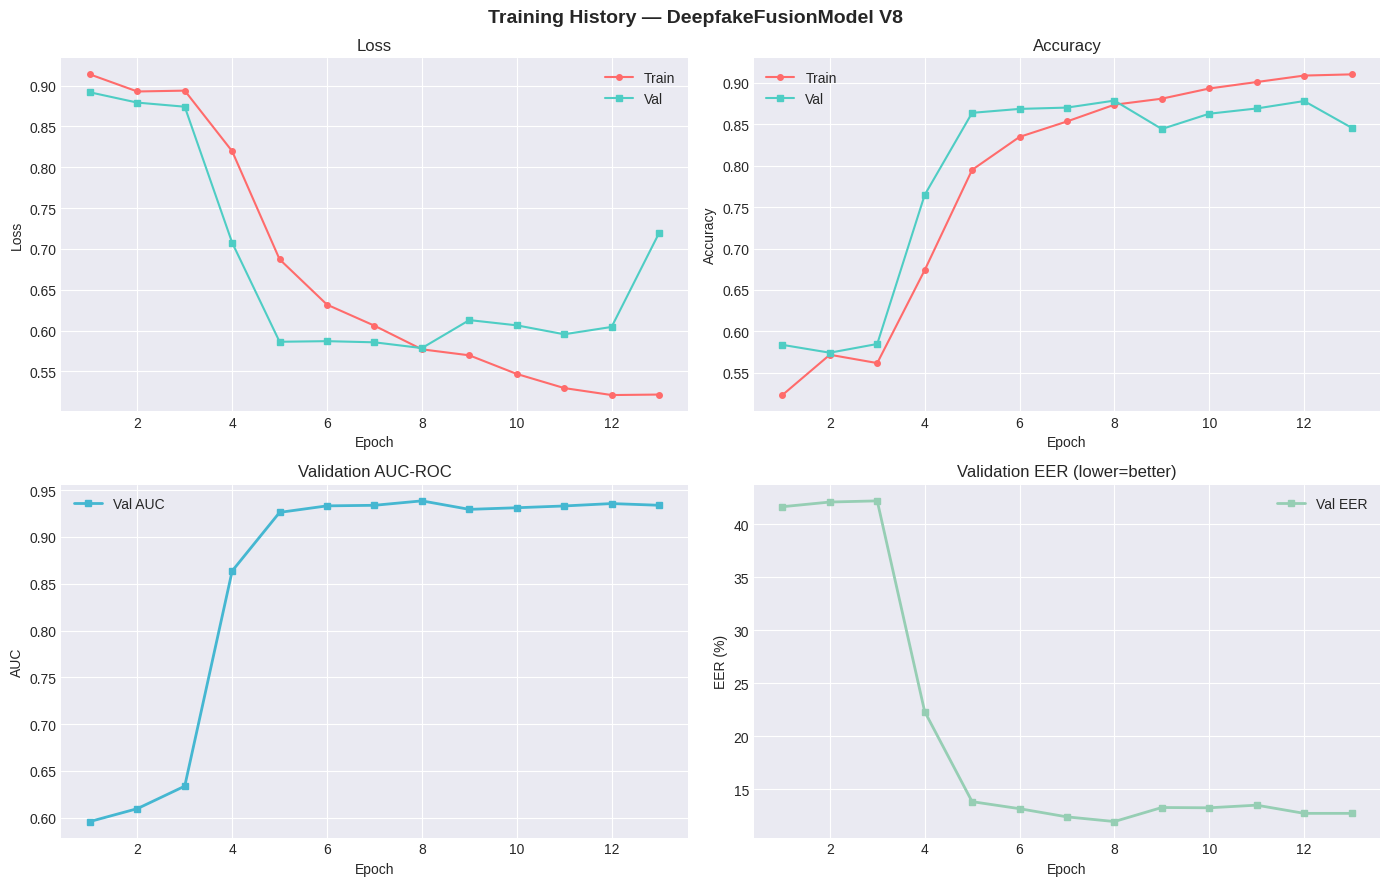

In [17]:
# Training curves
epochs_r = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Training History — DeepfakeFusionModel V8', fontsize=14, fontweight='bold')

axes[0,0].plot(epochs_r, history['train_loss'], 'o-', color='#FF6B6B',
               label='Train', markersize=4)
axes[0,0].plot(epochs_r, history['val_loss'],   's-', color='#4ECDC4',
               label='Val',   markersize=4)
axes[0,0].set(title='Loss', xlabel='Epoch', ylabel='Loss'); axes[0,0].legend()

axes[0,1].plot(epochs_r, history['train_acc'], 'o-', color='#FF6B6B',
               label='Train', markersize=4)
axes[0,1].plot(epochs_r, history['val_acc'],   's-', color='#4ECDC4',
               label='Val',   markersize=4)
axes[0,1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy'); axes[0,1].legend()

axes[1,0].plot(epochs_r, history['val_auc'], 's-', color='#45B7D1',
               linewidth=2, markersize=4, label='Val AUC')
axes[1,0].set(title='Validation AUC-ROC', xlabel='Epoch', ylabel='AUC')
axes[1,0].legend()

axes[1,1].plot(epochs_r, history['val_eer'], 's-', color='#96CEB4',
               linewidth=2, markersize=4, label='Val EER')
axes[1,1].set(title='Validation EER (lower=better)', xlabel='Epoch', ylabel='EER (%)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(os.path.join(Config.SAVE_DIR, 'training_curves_v8.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6: Evaluation — FF++ Validation

Loaded best model from epoch 8


Eval: FaceForensics++ Val (C23):   0%|          | 0/237 [00:00<?, ?it/s]


RESULTS — FaceForensics++ Val (C23)
  Accuracy  : 87.86%
  AUC-ROC   : 0.9386
  EER       : 11.93%
  F1-Score  : 0.8749
  Precision : 0.8617
  Recall    : 0.8884

              precision    recall  f1-score   support

        Real       0.90      0.87      0.88       990
        Fake       0.86      0.89      0.87       905

    accuracy                           0.88      1895
   macro avg       0.88      0.88      0.88      1895
weighted avg       0.88      0.88      0.88      1895



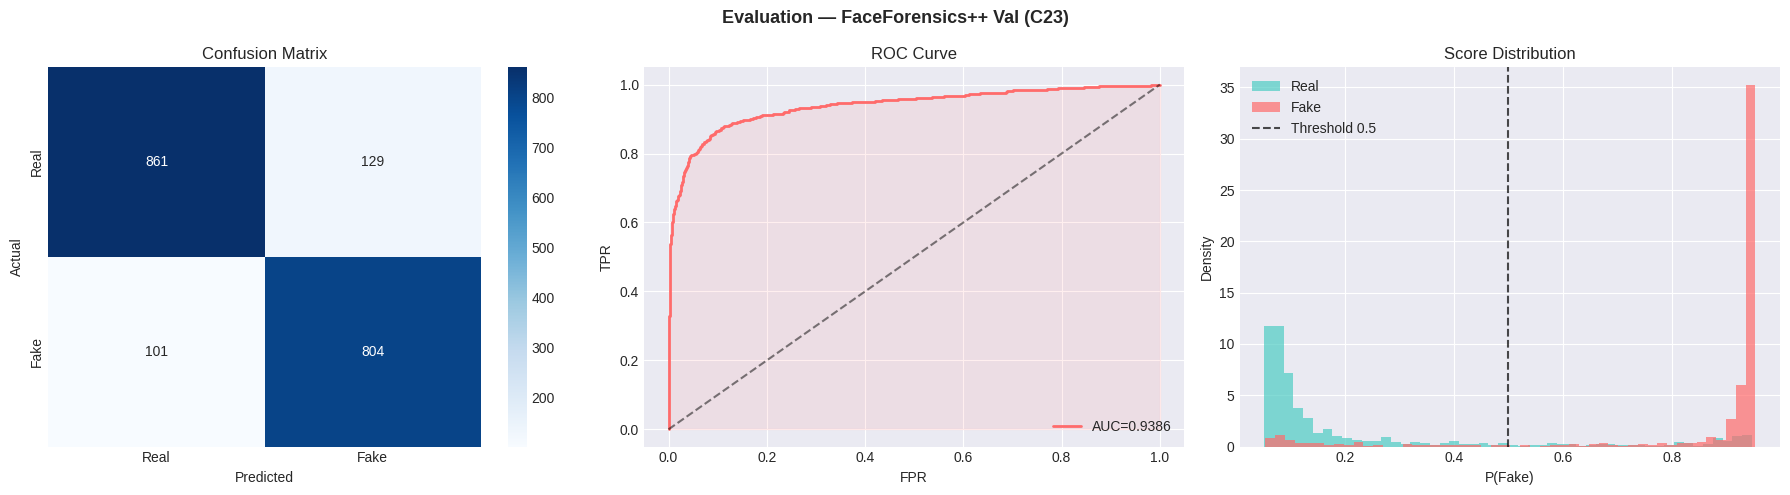

In [18]:
def evaluate_model(model, dataloader, dataset_name='Dataset'):
    '''Full evaluation: metrics + Confusion Matrix + ROC + Score Distribution.'''
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for imgs, bios, labels in tqdm(dataloader, desc=f'Eval: {dataset_name}'):
            imgs, bios = imgs.to(device), bios.to(device)
            out = model(imgs, bios)
            # Handle tuple output from V7 model and single tensor from ablation models
            outputs = out[0].squeeze(1) if isinstance(out, tuple) else out.squeeze(1)
            all_labels.extend(labels.numpy())
            all_probs.extend(outputs.cpu().numpy())

    y_true = np.array(all_labels)
    y_prob = np.array(all_probs)
    y_pred = (y_prob > 0.5).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    eer  = compute_eer(y_true, y_prob)
    f1   = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)

    print(f'\n{"=" * 52}')
    print(f'RESULTS — {dataset_name}')
    print(f'{"=" * 52}')
    print(f'  Accuracy  : {acc * 100:.2f}%')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  EER       : {eer:.2f}%')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

    # Plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Evaluation — {dataset_name}', fontsize=13, fontweight='bold')

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'], ax=axes[0])
    axes[0].set(xlabel='Predicted', ylabel='Actual', title='Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='#FF6B6B', linewidth=2, label=f'AUC={auc:.4f}')
    axes[1].plot([0,1],[0,1], 'k--', alpha=0.5)
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='#FF6B6B')
    axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
    axes[1].legend(loc='lower right')

    axes[2].hist(y_prob[y_true==0], bins=50, alpha=0.7, color='#4ECDC4',
                 label='Real', density=True)
    axes[2].hist(y_prob[y_true==1], bins=50, alpha=0.7, color='#FF6B6B',
                 label='Fake', density=True)
    axes[2].axvline(0.5, color='black', ls='--', alpha=0.7, label='Threshold 0.5')
    axes[2].set(xlabel='P(Fake)', ylabel='Density', title='Score Distribution')
    axes[2].legend()

    plt.tight_layout()
    safe_name = dataset_name.lower().replace(' ','_').replace('(','').replace(')','')
    plt.savefig(os.path.join(Config.SAVE_DIR, f'eval_{safe_name}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'auc': auc, 'eer': eer,
            'f1': f1, 'precision': prec, 'recall': rec}


# Load best checkpoint
model.load_state_dict(torch.load(best_path, map_location=device))
print(f'Loaded best model from epoch {best_epoch}')

ff_results = evaluate_model(model, val_loader, 'FaceForensics++ Val (C23)')


---
## Section 6.5: Cross-Attention Weight Analysis (empirical evaluation)

This section exists to empirically prove that `softmax` in
`CrossAttentionFusion` **works properly** — creating a probability distribution
over the actual temporal tokens, not degenerating to a constant.

With `K, V` having multiple tokens, attention weights form a distribution that can vary between
samples, across training epochs, and (ideally) between Real vs Fake classes.

If the chart below shows **non-zero variance** and **non-uniform distribution
1/4 = 0.25 for all tokens**, it's evidence that attention actually "works"
rather than being a disguised fixed linear projection.


Extracting attention:   0%|          | 0/237 [00:00<?, ?it/s]

Collected attention weights: (504, 32)
Mean weight per token (all samples): [0.1903 0.0116 0.0544 0.0272 0.0271 0.0271 0.0269 0.0266 0.0264 0.0262
 0.026  0.0259 0.0259 0.026  0.0261 0.0263 0.0264 0.0265 0.0266 0.0266
 0.0263 0.0261 0.026  0.026  0.026  0.026  0.0261 0.0263 0.0265 0.0313
 0.0196 0.0077]
Std  weight per token (all samples): [0.0998 0.0038 0.0329 0.0106 0.0095 0.0094 0.0091 0.0085 0.0083 0.0083
 0.0081 0.0082 0.0084 0.0084 0.0084 0.0087 0.0089 0.0086 0.0083 0.0086
 0.0089 0.0088 0.0087 0.0084 0.0082 0.0083 0.0088 0.0096 0.0107 0.0145
 0.0092 0.0044]
Per-sample std (mean over samples): 0.0317
  → If std ≈ 0 across all samples: attention is almost uniform,
    mathematically valid but weak in "dynamic selectivity".
  → If std > 0 clearly: model is distinguishing between different temporal tokens.


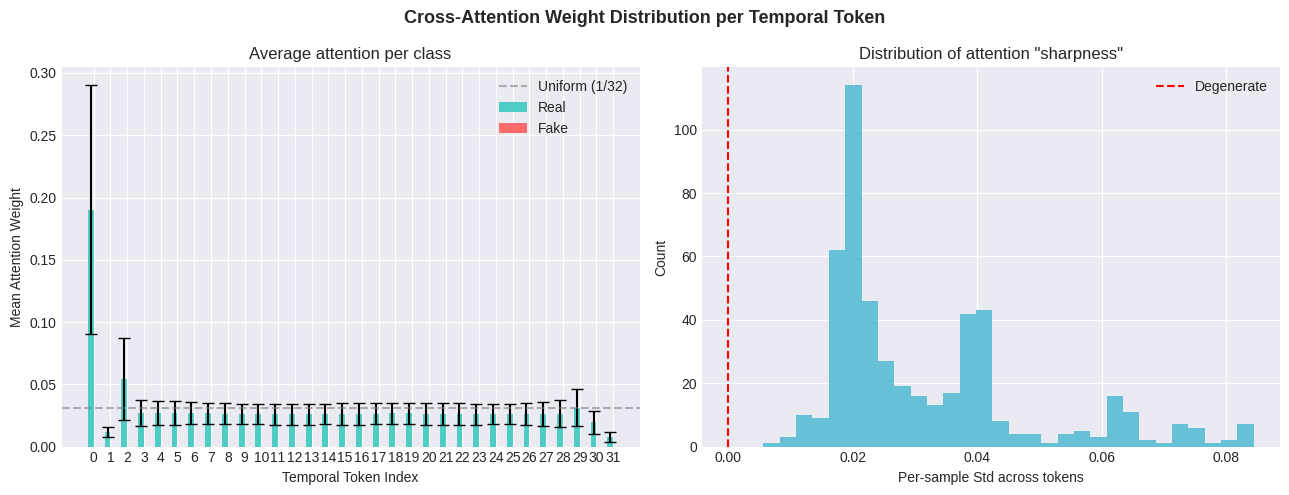


Note for paper: if Real vs Fake shows different attention patterns
attention patterns (e.g., Fake focuses heavily on 1-2 specific tokens, Real is more evenly distributed
this is direct empirical evidence supporting the claim "the network
focuses on regions where biological liveness is disrupted" trong Conclusion.


In [20]:
@torch.no_grad()
def extract_attention_weights(model, dataloader, max_samples=500):
    '''
    Run forward with return_attn=True on the val set, collecting:
      - attn_weights: (N, BIO_TOKENS) — attention weights per sample
      - labels:       (N,)            — 0=real, 1=fake
    '''
    model.eval()
    all_attn, all_labels = [], []
    n_collected = 0

    for imgs, bios, labels in tqdm(dataloader, desc='Extracting attention'):
        imgs, bios = imgs.to(device), bios.to(device)
        # FIX: The model returns 3 values when return_attn=True (main_out, aux_out, attn_w)
        _, _aux, attn_w = model(imgs, bios, return_attn=True)  # unpack main, aux, attn
        all_attn.append(attn_w.cpu().numpy())
        all_labels.append(labels.numpy())
        n_collected += imgs.size(0)
        if n_collected >= max_samples:
            break

    return np.concatenate(all_attn, axis=0), np.concatenate(all_labels, axis=0)


attn_weights, attn_labels = extract_attention_weights(model, val_loader)

print(f'Collected attention weights: {attn_weights.shape}')
print(f'Mean weight per token (all samples): {attn_weights.mean(axis=0).round(4)}')
print(f'Std  weight per token (all samples): {attn_weights.std(axis=0).round(4)}')
print(f'Per-sample std (mean over samples): {attn_weights.std(axis=1).mean():.4f}')
print(f'  → If std ≈ 0 across all samples: attention is almost uniform,')
print(f'    mathematically valid but weak in "dynamic selectivity".')
print(f'  → If std > 0 clearly: model is distinguishing between different temporal tokens.')

# ── Compare attention distribution: Real vs Fake ───────────────────────────────────
real_attn = attn_weights[attn_labels == 0]
fake_attn = attn_weights[attn_labels == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cross-Attention Weight Distribution per Temporal Token',
             fontsize=13, fontweight='bold')

x = np.arange(Config.BIO_TOKENS)
width = 0.35
axes[0].bar(x - width/2, real_attn.mean(axis=0), width,
            yerr=real_attn.std(axis=0), label='Real', color='#4ECDC4', capsize=4)
axes[0].bar(x + width/2, fake_attn.mean(axis=0), width,
            yerr=fake_attn.std(axis=0), label='Fake', color='#FF6B6B', capsize=4)
axes[0].axhline(1/Config.BIO_TOKENS, color='gray', ls='--', alpha=0.6,
                label=f'Uniform (1/{Config.BIO_TOKENS})')
axes[0].set(xlabel='Temporal Token Index', ylabel='Mean Attention Weight',
           title='Average attention per class', xticks=x)
axes[0].legend()

axes[1].hist(attn_weights.std(axis=1), bins=30, color='#45B7D1', alpha=0.8)
axes[1].axvline(0, color='red', ls='--', label='Degenerate')
axes[1].set(xlabel='Per-sample Std across tokens', ylabel='Count',
           title='Distribution of attention "sharpness"')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(Config.SAVE_DIR, 'attention_analysis_v7.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('\nNote for paper: if Real vs Fake shows different attention patterns')
print('attention patterns (e.g., Fake focuses heavily on 1-2 specific tokens, Real is more evenly distributed')
print('this is direct empirical evidence supporting the claim "the network')
print('focuses on regions where biological liveness is disrupted" trong Conclusion.')


---
## Section 7: Cross-Dataset Evaluation — Celeb-DF-v2

Model has **never seen** Celeb-DF-v2 — this is a true generalization test.

Eval: Celeb-DF-v2 (Cross-Dataset):   0%|          | 0/3930 [00:00<?, ?it/s]


RESULTS — Celeb-DF-v2 (Cross-Dataset)
  Accuracy  : 61.01%
  AUC-ROC   : 0.7058
  EER       : 35.23%
  F1-Score  : 0.7268
  Precision : 0.9265
  Recall    : 0.5979

              precision    recall  f1-score   support

        Real       0.21      0.69      0.32      4170
        Fake       0.93      0.60      0.73     27265

    accuracy                           0.61     31435
   macro avg       0.57      0.64      0.52     31435
weighted avg       0.83      0.61      0.67     31435



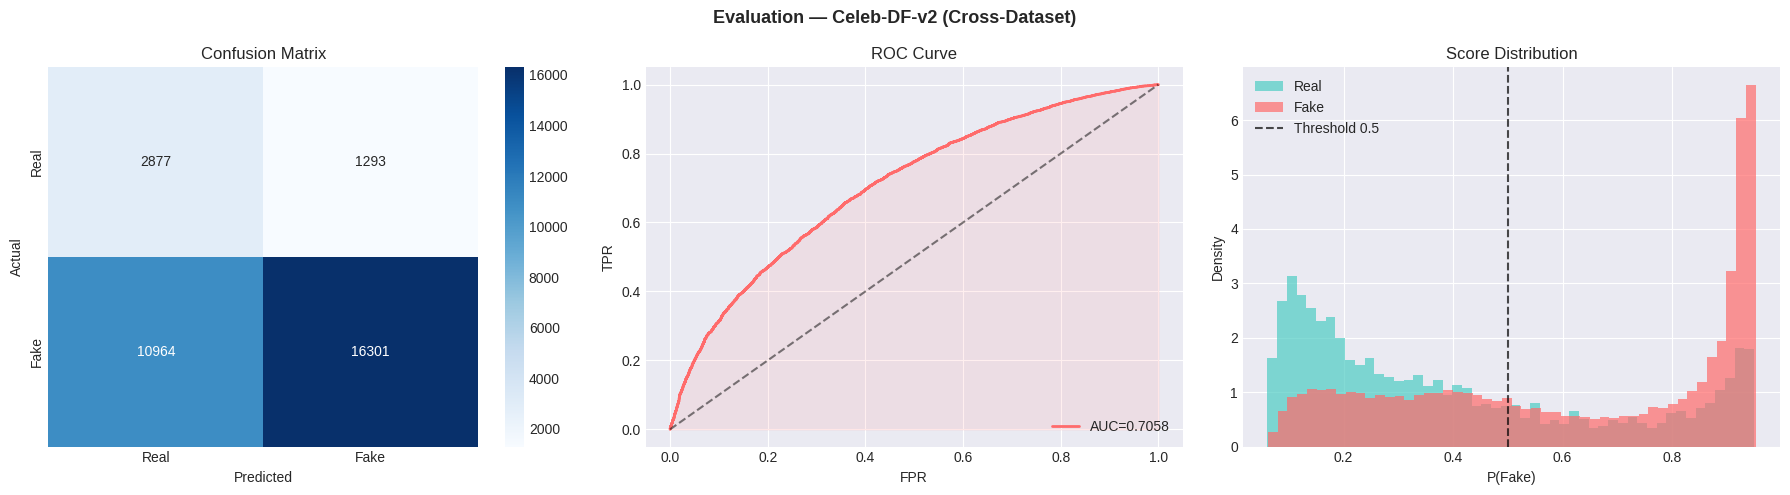


COMPARISON TABLE
Metric             FF++ Val    Celeb-DF-v2
--------------------------------------------
accuracy             87.86%          61.01%
auc                  0.9386          0.7058
eer                1193.37%        3522.78%
f1                   0.8749          0.7268
precision            0.8617          0.9265
recall               0.8884          0.5979


In [21]:
if len(test_loader) == 0:
    print('ERROR: Celeb-DF-v2 test_loader is empty (0 samples).')
    print('Please go back to run the Extract Celeb-DF-v2 clips cell (Section 1), then re-run the DataLoader cell (Section 2) to update.')
else:
    celeb_results = evaluate_model(model, test_loader, 'Celeb-DF-v2 (Cross-Dataset)')

    print('\n' + '=' * 72)
    print('COMPARISON TABLE')
    print('=' * 72)
    print(f'{"Metric":<14} {"FF++ Val":>12} {"Celeb-DF-v2":>14}')
    print('-' * 44)
    for k in ['accuracy', 'auc', 'eer', 'f1', 'precision', 'recall']:
        ff_v    = ff_results[k]
        celeb_v = celeb_results[k]
        if k in ('accuracy', 'eer'):
            print(f'{k:<14} {ff_v*100:>11.2f}%  {celeb_v*100:>13.2f}%')
        else:
            print(f'{k:<14} {ff_v:>12.4f}  {celeb_v:>14.4f}')

---
## Section 8: Ablation Study (Fair Comparison)

**Design ensures fairness:**
- All variants: `ABLATION_EPOCHS` epochs, same scheduler, same gradient clip
- Swin-based variants: differential LR (Swin=2e-5, other=1e-4) consistent
- rPPG-only variant: uniform LR=1e-4 (no Swin)
- This is a quick comparison — explicitly noted, do not use to claim absolute numbers

| Variant | Spatial | Temporal Bio | Fusion |
|---|---|---|---|
| **A** Swin Only | Swin-Tiny | ✗ | — |
| **B** rPPG Only | ✗ | rPPGNetwork3D | — |
| **C** Concat | Swin-Tiny | rPPGNetwork3D | Cat(768+64) → MLP |
| **D** Full (V7) | Swin-Tiny | rPPGNetwork3D | Multi-Head CrossAttn |


In [22]:
class SwinOnlyModel(nn.Module):
    '''Ablation A: Spatial features only (Swin-Small, pretrained).'''
    def __init__(self):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224', pretrained=True, num_classes=0)
        self.classifier = nn.Sequential(
            nn.Linear(768, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 1), nn.Sigmoid())

    def forward(self, spatial_input, bio_input):
        return self.classifier(self.swin(spatial_input))


class rPPGOnlyModel(nn.Module):
    '''
    Ablation B: Physiological features only (rPPGNetwork3D from scratch).

    FIX 3: Uses TemporalMLP instead of mean pooling.
      Mean pooling: tokens.mean(dim=1) → destroys temporal ORDER of rPPG signal.
      TemporalMLP:  Flatten → Linear → sees all positions in original sequence.

    FIX 5 + Label smoothing: rPPG branch trains from random init (no pretrained weights).
      In ablation_train_eval, this variant uses standard BCE (no label smoothing).
      Rationale: label smoothing penalizes confident predictions — harmful for a weak
      classifier that needs strong gradient signal early in training.
    '''
    def __init__(self):
        super().__init__()
        self.rppg_net = rPPGNetwork3D(
            bio_dim=Config.BIO_DIM, bio_tokens=Config.BIO_TOKENS)
        # FIX 3: TemporalMLP instead of mean pool
        self.temporal_mlp = TemporalMLP(
            bio_tokens=Config.BIO_TOKENS,
            bio_dim=Config.BIO_DIM,
            out_dim=128
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 1), nn.Sigmoid())

    def forward(self, spatial_input, bio_input):
        tokens = self.rppg_net(bio_input)        # (B, BIO_TOKENS, BIO_DIM)
        feat   = self.temporal_mlp(tokens)        # (B, 128) — order preserved
        return self.classifier(feat)


class ConcatFusionModel(nn.Module):
    '''
    Ablation C: Concat fusion — Swin + rPPG, no attention.
    Also uses TemporalMLP for the bio branch (same fix as rPPGOnlyModel).
    Concatenates spatial (768) + temporal (128) → MLP → prediction.
    '''
    def __init__(self):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224', pretrained=True, num_classes=0)
        self.rppg_net = rPPGNetwork3D(
            bio_dim=Config.BIO_DIM, bio_tokens=Config.BIO_TOKENS)
        self.temporal_mlp = TemporalMLP(
            bio_tokens=Config.BIO_TOKENS,
            bio_dim=Config.BIO_DIM,
            out_dim=128
        )
        in_dim = Config.SPATIAL_DIM + 128
        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1), nn.Sigmoid())

    def forward(self, spatial_input, bio_input):
        s = self.swin(spatial_input)
        b_tokens = self.rppg_net(bio_input)
        b = self.temporal_mlp(b_tokens)
        return self.classifier(torch.cat((s, b), dim=1))


print('Ablation variants defined (all use TemporalMLP, no mean pooling).')


Ablation variants defined (all use TemporalMLP, no mean pooling).


In [23]:
def ablation_train_eval(model_cls, variant_name):
    '''
    Train and evaluate an ablation variant.

    FIX 5 (V8): ABLATION_EPOCHS=25 for ALL variants.
      V7 used 10 epochs, which is unfair because:
        - Swin-based models: ImageNet pretrained → converge fast
        - rPPG-only model:   random init → needs many more epochs
      Setting 25 epochs levels the playing field.

    FIX 9 (V8): rPPG-only variant uses BCE (no label smoothing).
      Label smoothing discourages confident predictions, which hurts a weak
      classifier (rPPG from random init) that needs strong gradient early on.
    '''
    print(f'\n{"─"*55}')
    print(f'{variant_name}')
    print(f'  Epochs: {Config.ABLATION_EPOCHS} | ACCUM: {Config.ACCUM_STEPS}'
          f' | Effective batch: {Config.BATCH_SIZE * Config.ACCUM_STEPS}')
    print('─'*55)

    m = model_cls().to(device)

    # FIX 9: rPPG-only → plain BCE (no label smoothing)
    is_rppg_only = 'rPPG' in variant_name and 'Swin' not in variant_name
    crit = nn.BCELoss() if is_rppg_only else LabelSmoothingBCELoss()
    if is_rppg_only:
        print('  [rPPG-only] Using BCE (no label smoothing) for stronger gradient.')

    # Differential LR: Swin pretrained → LR_SWIN; random-init layers → LR_OTHER
    try:
        swin_p  = list(m.swin.parameters())
        other_p = [p for n, p in m.named_parameters() if not n.startswith('swin')]
        opt = optim.AdamW([
            {'params': swin_p,  'lr': Config.LR_SWIN},
            {'params': other_p, 'lr': Config.LR_OTHER}
        ], weight_decay=Config.WEIGHT_DECAY)
    except AttributeError:
        opt = optim.AdamW(m.parameters(), lr=Config.LR_OTHER,
                          weight_decay=Config.WEIGHT_DECAY)

    sched = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=Config.ABLATION_EPOCHS, eta_min=1e-7)

    for ep in range(1, Config.ABLATION_EPOCHS + 1):
        m.train()
        optimizer_stepped = False
        opt.zero_grad()

        for step, (imgs, bios, labels) in enumerate(
                tqdm(train_loader, desc=f'  Ep{ep:02d}', leave=False)):
            imgs, bios, labels = imgs.to(device), bios.to(device), labels.to(device)
            out = m(imgs, bios)

            # Handle V8 tuple (main, aux) vs single tensor (baselines)
            if isinstance(out, tuple):
                main_out, aux_out = out
                main_loss = crit(main_out.squeeze(1), labels)
                aux_loss  = crit(aux_out.squeeze(1), labels)
                loss = (main_loss + 0.3 * aux_loss) / Config.ACCUM_STEPS
            else:
                loss = crit(out.squeeze(1), labels) / Config.ACCUM_STEPS

            loss.backward()

            if (step + 1) % Config.ACCUM_STEPS == 0 or (step+1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(m.parameters(), Config.GRAD_CLIP)
                opt.step()
                opt.zero_grad()

        sched.step()

    # Evaluate
    m.eval()
    v_labels, v_probs = [], []
    with torch.no_grad():
        for imgs, bios, labels in val_loader:
            imgs, bios = imgs.to(device), bios.to(device)
            out = m(imgs, bios)
            out = out[0].squeeze(1) if isinstance(out, tuple) else out.squeeze(1)
            v_labels.extend(labels.numpy())
            v_probs.extend(out.cpu().numpy())

    y_true = np.array(v_labels)
    y_prob = np.array(v_probs)
    acc = accuracy_score(y_true, (y_prob > 0.5).astype(int))
    auc = roc_auc_score(y_true, y_prob)
    eer = compute_eer(y_true, y_prob)
    print(f'  → Acc={acc*100:.2f}%  AUC={auc:.4f}  EER={eer:.2f}%')

    del m, opt, sched, crit
    torch.cuda.empty_cache(); gc.collect()
    return {'accuracy': acc, 'auc': auc, 'eer': eer}


print(f'ABLATION STUDY  |  {Config.ABLATION_EPOCHS} epochs (fair for all variants)')
print('=' * 60)

ablation_results = {}
for name, cls in [
    ('A: Swin Only',           SwinOnlyModel),
    ('B: rPPG 3D Only',        rPPGOnlyModel),
    ('C: Concat Fusion',       ConcatFusionModel),
    ('D: Cross-Attn V8 (Full)', DeepfakeFusionModelV8),
]:
    ablation_results[name] = ablation_train_eval(cls, name)


ABLATION STUDY  |  25 epochs (fair for all variants)

───────────────────────────────────────────────────────
A: Swin Only
  Epochs: 25 | ACCUM: 4 | Effective batch: 32
───────────────────────────────────────────────────────


  Ep01:   0%|          | 0/945 [00:00<?, ?it/s]

  Ep02:   0%|          | 0/945 [00:00<?, ?it/s]

  Ep03:   0%|          | 0/945 [00:00<?, ?it/s]

  Ep04:   0%|          | 0/945 [00:00<?, ?it/s]

...

  Ep22:   0%|          | 0/945 [00:00<?, ?it/s]

  Ep23:   0%|          | 0/945 [00:00<?, ?it/s]

  Ep24:   0%|          | 0/945 [00:00<?, ?it/s]

  Ep25:   0%|          | 0/945 [00:00<?, ?it/s]

  → Acc=87.02%  AUC=0.9340  EER=13.04%



ABLATION RESULTS
Variant                        Accuracy      AUC      EER
----------------------------------------------------------
A: Swin Only                     87.34%   0.9256   12.12%
B: rPPG 3D Only                  61.85%   0.6705   38.89%
C: Concat Fusion                 88.28%   0.9322   10.94%
D: Cross-Attn V8 (Full)          87.02%   0.9340   13.04% ←


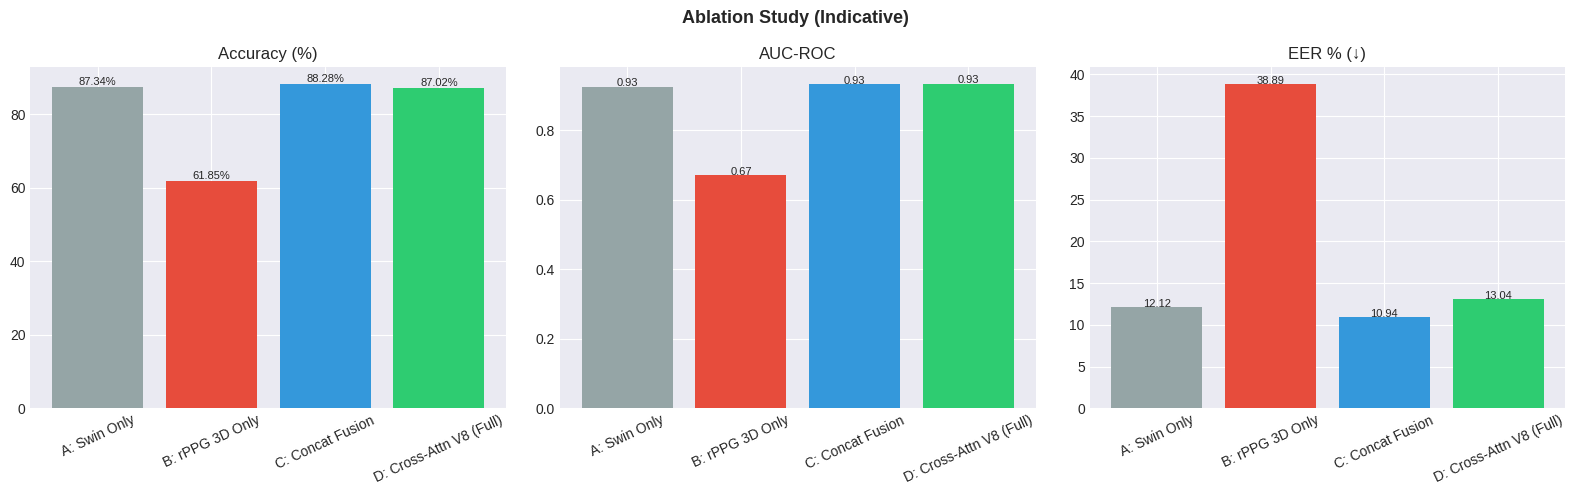

In [24]:
print('\n' + '=' * 58)
print('ABLATION RESULTS')
print('=' * 58)
print(f'{"Variant":<28} {"Accuracy":>10} {"AUC":>8} {"EER":>8}')
print('-' * 58)
for name, r in ablation_results.items():
    marker = ' ←' if 'Full' in name else ''
    print(f'{name:<28} {r["accuracy"]*100:>9.2f}%  {r["auc"]:>7.4f}  '
          f'{r["eer"]:>6.2f}%{marker}')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Ablation Study (Indicative)', fontsize=13, fontweight='bold')
names  = list(ablation_results.keys())
colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']

for ax, metric, label, scale in [
    (axes[0], 'accuracy', 'Accuracy (%)', 100),
    (axes[1], 'auc',      'AUC-ROC',       1),
    (axes[2], 'eer',      'EER % (↓)',     1),
]:
    vals = [ablation_results[n][metric] * scale for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.5 if scale==100 else 0.002),
                f'{v:.2f}{"%" if scale==100 else ""}',
                ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(Config.SAVE_DIR, 'ablation_v8.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9: Export & Final Summary

In [25]:
model.load_state_dict(torch.load(best_path, map_location=device))

final_name    = f'fusion_model_v8_auc{best_val_auc:.3f}_ep{best_epoch:02d}.pth'
final_path    = os.path.join(Config.SAVE_DIR, final_name)
backend_path  = os.path.join(Config.SAVE_DIR, 'fusion_model_v8_best.pth')
torch.save(model.state_dict(), final_path)
torch.save(model.state_dict(), backend_path)

print('=' * 60)
print('TRAINING COMPLETE — FINAL SUMMARY')
print('=' * 60)
total_p = sum(p.numel() for p in model.parameters())
print(f'  Model:            DeepfakeFusionModel V8')
print(f'  Total parameters: {total_p:,}')
print(f'  Best epoch:       {best_epoch}')
print(f'  Best val AUC:     {best_val_auc:.4f}')
print(f'\n  FF++ Val results:')
for k, v in ff_results.items():
    s = f'{v*100:.2f}%' if k in ('accuracy','eer') else f'{v:.4f}'
    print(f'    {k:<12}: {s}')
print(f'\n  Celeb-DF-v2 (Cross-Dataset):')
for k, v in celeb_results.items():
    s = f'{v*100:.2f}%' if k in ('accuracy','eer') else f'{v:.4f}'
    print(f'    {k:<12}: {s}')
print(f'\n  Saved to: {Config.SAVE_DIR}/')
!ls -lh "{Config.SAVE_DIR}/"
print('\nDone!')

TRAINING COMPLETE — FINAL SUMMARY
  Model:            DeepfakeFusionModel V8
  Total parameters: 65,026,684
  Best epoch:       8
  Best val AUC:     0.9386

  FF++ Val results:
    accuracy    : 87.86%
    auc         : 0.9386
    eer         : 1193.37%
    f1          : 0.8749
    precision   : 0.8617
    recall      : 0.8884

  Celeb-DF-v2 (Cross-Dataset):
    accuracy    : 61.01%
    auc         : 0.7058
    eer         : 3522.78%
    f1          : 0.7268
    precision   : 0.9265
    recall      : 0.5979

  Saved to: /content/drive/MyDrive/DoAn_Nhom4/weights_v8/
total 1.3G
-rw------- 1 root root  80K Jun 29 10:28 ablation_v8.png
-rw------- 1 root root  85K Jun 29 03:28 attention_analysis_v7.png
-rw------- 1 root root 249M Jun 29 02:52 best_model_v8.pth
-rw------- 1 root root 108K Jun 29 03:44 eval_celeb-df-v2_cross-dataset.png
-rw------- 1 root root  98K Jun 29 03:21 eval_faceforensics++_val_c23.png
-rw------- 1 root root 249M Jun 29 10:28 fusion_model_v8_auc0.939_ep08.pth
-rw-----